<a href="https://colab.research.google.com/github/navirath/ML-lab/blob/main/Copy_of_Regresion_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import pandas as pd
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
  try:
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
    print(f"Successfully loaded data from uploaded file: {fn}")
    print("First 5 rows of the DataFrame:")
    display(df.head())
  except Exception as e:
    print(f"An error occurred while reading the uploaded file {fn}: {e}")

Saving canada_per_capita_income.csv to canada_per_capita_income.csv
Successfully loaded data from uploaded file: canada_per_capita_income.csv
First 5 rows of the DataFrame:


,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [ ]:
from sklearn import linear_model
import numpy as np

# Prepare the data
X = df[['year']]
y = df['per capita income (US$)']

# Create and train the linear regression model
reg = linear_model.LinearRegression()
reg.fit(X, y)

# Predict per capita income for the year 2020
year_2020 = np.array([[2020]])
predicted_income_2020 = reg.predict(year_2020)

print(f"Predicted Canadian per capita income in 2020: ${predicted_income_2020[0]:,.2f}")

Predicted Canadian per capita income in 2020: $41,288.69


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The code above performs the following steps:
1.  **Data Preparation**: It extracts the 'year' column as the feature (`X`) and 'per capita income (US$)' as the target (`y`).
2.  **Model Training**: A `LinearRegression` model from `sklearn` is initialized and trained using the `fit` method on the historical data.
3.  **Prediction**: The trained model is then used to predict the per capita income for the year 2020. The result is printed to the console.

Please upload a CSV file containing your salary data. Ensure it has columns like 'YearsExperience' (for the feature) and 'Salary' (for the target variable). For example:

```csv
YearsExperience,Salary
1.1,39343.00
1.3,46205.00
1.5,37731.00
... (more data)
```

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from google.colab import files
import io
import numpy as np

uploaded = files.upload()

for fn in uploaded.keys():
    try:
        salary_df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
        print(f"Successfully loaded salary data from: {fn}")
        print("First 5 rows of the Salary DataFrame:")
        display(salary_df.head())

        # Drop rows with NaN values in 'YearsExperience' or 'Salary'
        salary_df_cleaned = salary_df.dropna(subset=['YearsExperience', 'Salary'])

        # Prepare the data assuming 'YearsExperience' as feature and 'Salary' as target
        X_salary = salary_df_cleaned[['YearsExperience']]
        y_salary = salary_df_cleaned['Salary']

        # Create and train the linear regression model
        salary_reg_model = LinearRegression()
        salary_reg_model.fit(X_salary, y_salary)

        print("\nLinear Regression Model Trained.")

        # Get user input for prediction
        years_experience = float(input("Enter years of experience to predict salary: "))

        # Predict salary
        predicted_salary = salary_reg_model.predict(np.array([[years_experience]]))

        print(f"Predicted Salary for {years_experience} years of experience: ${predicted_salary[0]:,.2f}")

    except KeyError as e:
        print(f"Error: Missing expected column in the uploaded file: {e}. Please ensure you have 'YearsExperience' and 'Salary' columns.")
    except Exception as e:
        print(f"An error occurred while processing the uploaded file {fn}: {e}")

Saving salary.csv to salary.csv
Successfully loaded salary data from: salary.csv
First 5 rows of the Salary DataFrame:


,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891



Linear Regression Model Trained.
Enter years of experience to predict salary: 12
Predicted Salary for 12.0 years of experience: $139,049.67


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


This code block first prompts you to upload a CSV file containing salary data. Once uploaded, it performs the following actions:

1.  **Loads Data**: Reads the uploaded CSV into a pandas DataFrame.
2.  **Prepares Data**: It assumes your CSV has a 'YearsExperience' column as the feature (`X_salary`) and a 'Salary' column as the target (`y_salary`).
3.  **Trains Model**: A `LinearRegression` model from `sklearn` is initialized and trained on your data.
4.  **User Input**: It then asks you to enter a number for 'years of experience'.
5.  **Predicts Salary**: The trained model uses your input to predict the corresponding salary.
6.  **Displays Result**: The predicted salary is printed to the console.

Error handling is included for missing columns or other issues during file processing.

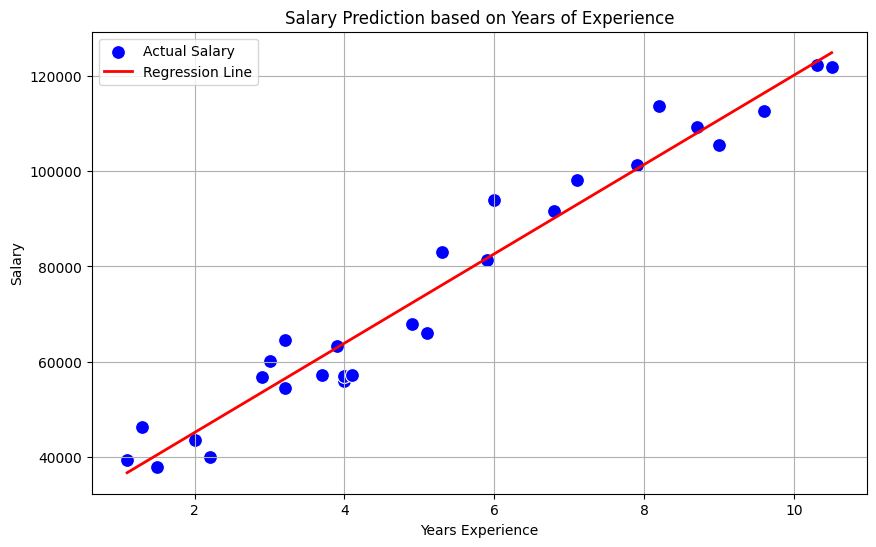

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_salary['YearsExperience'], y=y_salary, s=100, color='blue', label='Actual Salary')
plt.plot(X_salary, salary_reg_model.predict(X_salary), color='red', linewidth=2, label='Regression Line')
plt.title('Salary Prediction based on Years of Experience')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

This code block generates a scatter plot of your 'YearsExperience' versus 'Salary' data points and then overlays the linear regression line that the model has learned. This visualization allows you to see the relationship between years of experience and salary, as well as how well the regression model captures that trend.